# Deep Learning for Media
#### MPATE-GE 2039 - DM-GY 9103

---

## VR Chinese OCR Evaluation
### Robustness Analysis of Vision Models for Handwritten Chinese Character Recognition


## 1. Setup
Run this cell first — it adds the repo root to the Python path so all modules are importable.

In [38]:
# Add repo root to sys.path so imports work when running from /notebooks/
import sys, importlib
from pathlib import Path

repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import data.utils as data_utils
import utils.utils as utils_facade
import perturbations.perturbation_analysis as pa
import utils as u

importlib.reload(data_utils)
importlib.reload(utils_facade)
importlib.reload(pa)
importlib.reload(u)

# sanity check
import inspect
print(u.load_data.__module__, inspect.getsourcefile(u.load_data), u.load_data.__code__.co_firstlineno)


data.utils /Users/ek/Documents/GitHub/vr-chinese-ocr-eval/data/utils.py 167


In [39]:
# Fix random seeds for reproducibility across numpy and tensorflow
from numpy.random import seed
seed(124)
import tensorflow as tf
tf.keras.utils.set_random_seed(124)

## 2. Load Dataset & Apply Perturbations

**Dataset:** CASIA-HWDB2-line (offline handwritten Chinese) — https://huggingface.co/datasets/Teklia/CASIA-HWDB2-line

**Data split:**
- 1500 clean images sampled from train split
- Perturbation pool drawn from a *disjoint* set of indices (no overlap with clean)
- Final split: 80% train / 20% test
- Train further split: 80% train / 20% val

**Perturbation count:**
- From our presentation: ~1000–1500 clean + 200–300 perturbed
- Revised: 1500 clean + 9 types × 50 min per type = 450 perturbed
- Each image receives exactly one perturbation type (no combinations)

**Perturbation types (9 total):**

Lighting conditions:
- `radial_glare` — spotlight-style glare reflecting off the whiteboard surface
- `light_streak` — directional light band across the image
- `contrast_variation` — under/overexposed lighting in the room
- `white_balance_shift` — Quest auto white balance tinting the scene warm or cool

Camera / capture quality:
- `gaussian_noise` — sensor and camera noise
- `motion_blur` — camera shake or hand movement while writing
- `low_resolution` — degraded quality from the Meta Horizon cast stream

Geometric distortion:
- `perspective_warp` — camera not perfectly frontal to the whiteboard

Physical obstruction:
- `occlusion` — a rectangular block masking part of the character (e.g. hand in frame)

In [28]:
# Load CASIA dataset with perturbations applied
# Returns 6 values when return_perturbation_type=True:
#   X_train, X_test  — image arrays (object dtype, variable size PIL images)
#   y_train, y_test  — string labels (the Chinese character/sequence)
#   perturbation_type_train/test — None for clean samples, string label for perturbed
(
    X_train,
    X_test,
    y_train,
    y_test,
    perturbation_type_train,
    perturbation_type_test,
) = u.load_data(
    show_progress=True,
    perturb_count=None,           # auto-calculated from bucket settings
    include_combinations=False,    # use power-set combinations of perturbations
    min_per_perturb_bucket=50,    # at least 50 samples per perturbation bucket
    return_perturbation_type=True,
)

Applying perturbations: 100%|██████████| 450/450 [00:00<00:00, 6466.70it/s]


In [29]:
# Verify dataset dimensions: (n_samples,)
print("Train / Test sizes:")
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

Train / Test sizes:
(1560,) (390,) (1560,) (390,)


In [30]:
# Split train into train / validation (80 / 20)
X_train, X_val, y_train, y_val = u.split_data(X_train, y_train)
print("Train / Val sizes:")
print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

Train / Val sizes:
(1248,) (312,) (1248,) (312,)


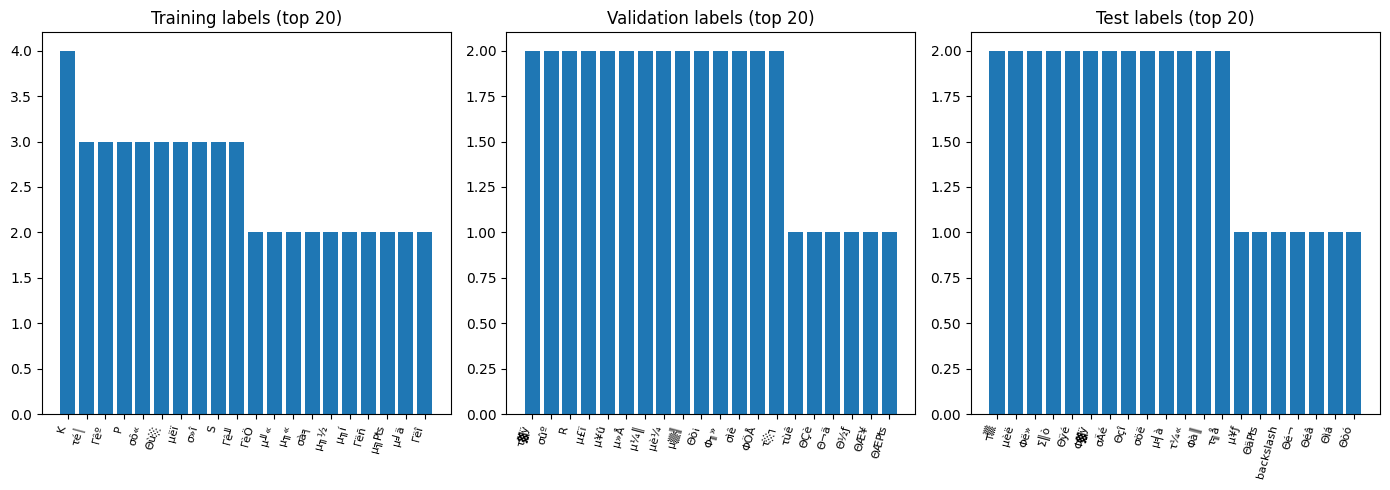

In [31]:
# Explore label frequency distribution across train / val / test
u.explore_data(X_train, y_train, y_test, y_val)

## 3. Perturbation Analysis

Visual validation that each perturbation type looks realistic for the Meta Quest whiteboard capture scenario.

**Grid layout:** rows = perturbation type, columns = sample images  
The first row is always the original clean image for reference.

In [41]:
# Import the perturbation analysis module from /perturbations/
from perturbations.perturbation_analysis import show_perturbation_grid

  Applying: radial_glare ...
  Applying: light_streak ...
  Applying: gaussian_noise ...
  Applying: contrast_variation ...
  Applying: occlusion ...
  Applying: perspective_warp ...
  Applying: motion_blur ...
  Applying: white_balance_shift ...
  Applying: low_resolution ...

Figure saved to: perturbation_analysis.png


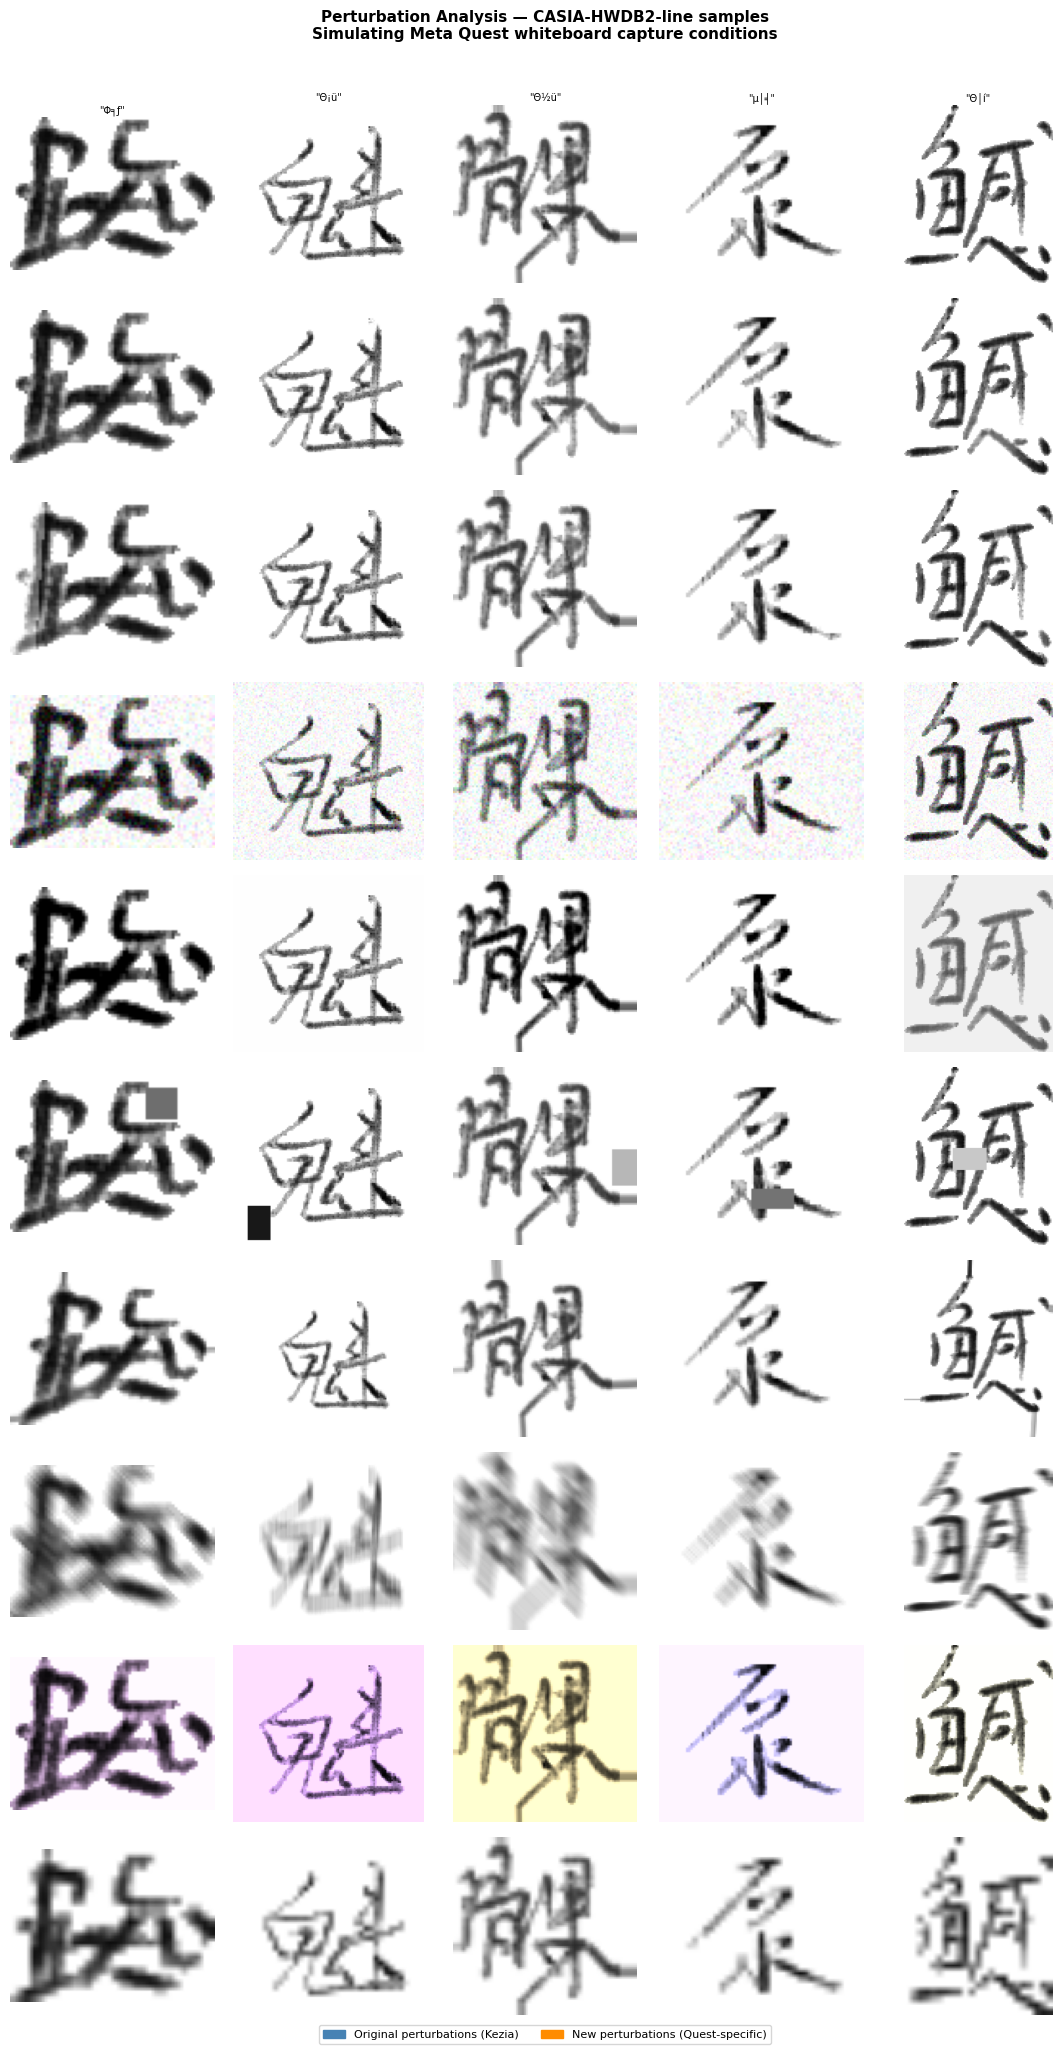


Done.


In [42]:
# Generate the visual analysis grid
# n_samples controls how many CASIA images are used as columns (keep <= 8 for readability)
# save_path saves the figure as a PNG alongside the notebook
show_perturbation_grid(images_raw=X_train, labels_raw=y_train,n_samples=5, save_path="perturbation_analysis.png")

## 4. Model Inference

Each model is run against the same test set (clean + perturbed).  
Results are stored per model so we can compare robustness across perturbation types in the next section.

Models:
- **CnOCR** — PyTorch-based, 20+ pretrained Chinese OCR models
- **ANCHOR** — VGG CNN built specifically for handwritten Chinese, 97% on ICDAR 2013
- **TrOCR** — Microsoft transformer model trained on handwritten and real-world text
- **DINOv3** — Meta self-supervised vision transformer (general-purpose baseline)

In [ ]:
# TODO (Kaylie / team): integrate model inference here
# Expected interface:
from models.cnocr_inference import run_cnocr
#   from models.anchor_inference import run_anchor
#   from models.trocr_inference import run_trocr
#   from models.dinov3_classifier import run_dinov3
#
predictions = {
    'cnocr':  run_cnocr(X_test),
#       'anchor': run_anchor(X_test),
#       'trocr':  run_trocr(X_test),
#       'dinov3': run_dinov3(X_test),
}
pass

## 5. Robustness Evaluation

Track accuracy and recall per model as perturbation type changes.  
Goal: identify which environmental conditions (glare, perspective, motion blur, etc.) break each model most.

In [ ]:
# TODO (Kaylie / Jasmine): evaluation and robustness plots
# Expected interface:

#   from evaluation.metrics import accuracy_per_perturbation_type
#   from evaluation.accuracy_curves import plot_robustness_curves
#   from evaluation.failure_analysis import show_failure_cases
pass

In [ ]:
print(predictions['cnocr'][:5])

In [ ]:
print(y_test[:5])